# Proyecto K-vecinos más Cercanos

#### Paso 1: Carga del conjunto de datos y EDA

In [50]:
import pandas as pd

url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep = ";")
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [51]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


In [52]:
print("\nDistribución de la variable objetivo:")
print(df["quality"].value_counts().sort_index())


Distribución de la variable objetivo:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [53]:
# Crear la variable objetivo label a partir de quality
def clasificar_vino(quality):
    if quality <= 4:
        return 0   # Baja calidad
    elif quality <= 6:
        return 1   # Calidad media
    else:
        return 2   # Alta calidad

df["label"] = df["quality"].apply(clasificar_vino)

In [54]:
print("\nDistribución de label:")
print(df["label"].value_counts().sort_index())


Distribución de label:
label
0      63
1    1319
2     217
Name: count, dtype: int64


#### Paso 2: Entrenar el modelo KNN

In [55]:
from sklearn.model_selection import train_test_split

X = df.drop(["quality", "label"], axis=1)
y = df["label"]

# 6. Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.neighbors import KNeighborsClassifier

k_inicial = 5
knn = KNeighborsClassifier(n_neighbors=k_inicial)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [58]:
y_pred = knn.predict(X_test_scaled)

#### Paso 3: Evaluación de rendimiento

In [59]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"\nExactitud del modelo={k_inicial}: {accuracy:.4f}")

print("\nExactitud del modelo:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Exactitud del modelo=5: 0.8187

Exactitud del modelo:
[[  0  13   0]
 [  1 243  20]
 [  0  24  19]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.87      0.92      0.89       264
           2       0.49      0.44      0.46        43

    accuracy                           0.82       320
   macro avg       0.45      0.45      0.45       320
weighted avg       0.78      0.82      0.80       320



#### Paso 4: Optimización de K

In [60]:
# Optimización de k
resultados = []

for k in range(1, 21):
    modelo = KNeighborsClassifier(n_neighbors = k)
    modelo.fit(X_train_scaled, y_train)
    pred_k = modelo.predict(X_test_scaled)
    acc_k = accuracy_score(y_test, pred_k)
    resultados.append(acc_k)

# Encontrar el mejor k
mejor_k = resultados.index(max(resultados)) + 1
mejor_accuracy = max(resultados)

print(f"\nMejor valor de k: {mejor_k}")
print(f"Mejor accuracy: {mejor_accuracy:.4f}")



Mejor valor de k: 11
Mejor accuracy: 0.8594


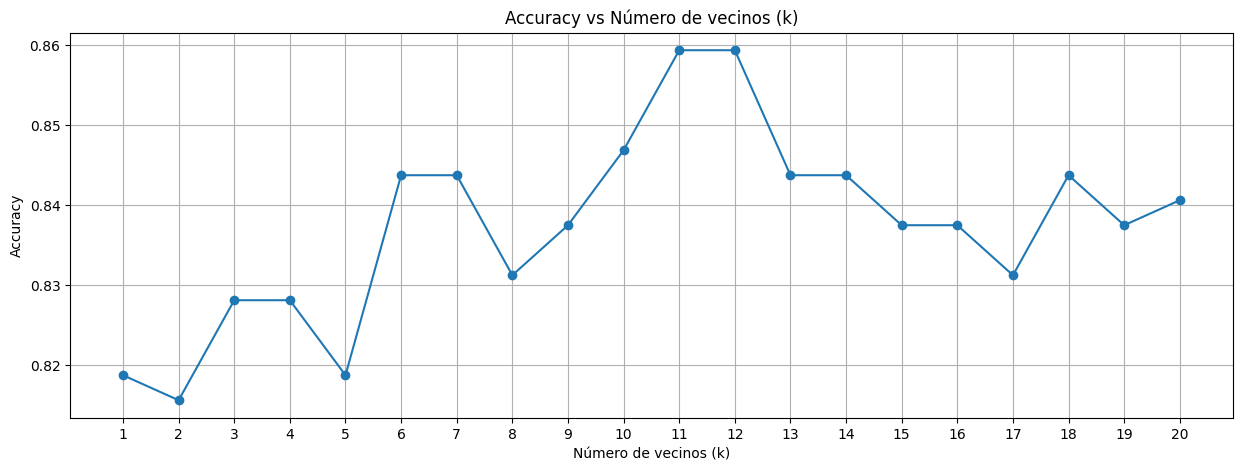

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(range(1, 21), resultados, marker="o")
plt.title("Accuracy vs Número de vecinos (k)")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

In [62]:
# Entrenar modelo final con el mejor k
modelo_final = KNeighborsClassifier(n_neighbors=mejor_k)
modelo_final.fit(X_train_scaled, y_train)
y_pred_final = modelo_final.predict(X_test_scaled)

print(f"\nEvaluación final con k={mejor_k}")
print(f"Accuracy final: {accuracy_score(y_test, y_pred_final):.4f}")

print("\nConfusion Matrix final:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report final:")
print(classification_report(y_test, y_pred_final))


Evaluación final con k=11
Accuracy final: 0.8594

Confusion Matrix final:
[[  0  13   0]
 [  0 250  14]
 [  0  18  25]]

Classification Report final:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.89      0.95      0.92       264
           2       0.64      0.58      0.61        43

    accuracy                           0.86       320
   macro avg       0.51      0.51      0.51       320
weighted avg       0.82      0.86      0.84       320



/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [65]:
# Función para predecir la calidad del vino
def predict_wine_quality(features):
    features_scaled = scaler.transform([features])
    pred = modelo_final.predict(features_scaled)[0]
    
    if pred == 0:
        return "Este vino probablemente sea de baja calidad 🍷"
    elif pred == 1:
        return "Este vino probablemente sea de calidad media 🍷"
    else:
        return "Este vino probablemente sea de alta calidad 🍷"

In [66]:
# Probamos la función
result = predict_wine_quality([
    7.4, 0.7, 0.0, 1.9, 0.076,
    11.0, 34.0, 0.9978, 3.51, 0.56, 9.4
])

print("Predicción de ejemplo:", result)

Predicción de ejemplo: Este vino probablemente sea de calidad media 🍷


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
